In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE #for imbalanced yes/no churn


import warnings

warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('customer.csv')
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Task 1

## Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
#convert total charges to num because MonthlyCharges aur tenure already in int and float but totalcharegs in obj
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# for checking dublicates (so there is no duplicate after running)
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()
#removing missing values(NaN)
df.dropna(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
# Drop customer id 
df.drop('customerID', axis=1, inplace=True)

In [10]:
print("Cleaned data:" , df.shape)

Cleaned data: (7032, 20)


## Task 2

## EDA

In [11]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032,7032.000000,7032,7032,7032.000000,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032.000000,7032.000000,7032
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3549,NaN,3639,4933,NaN,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,NaN,NaN,5163
mean,NaN,0.162400,NaN,NaN,32.421786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2283.300441,NaN
std,NaN,0.368844,NaN,NaN,24.545260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2266.771362,NaN
min,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.862500,3794.737500,NaN


In [12]:
df.to_csv("dataset.csv", index=False)

## Churn vs all

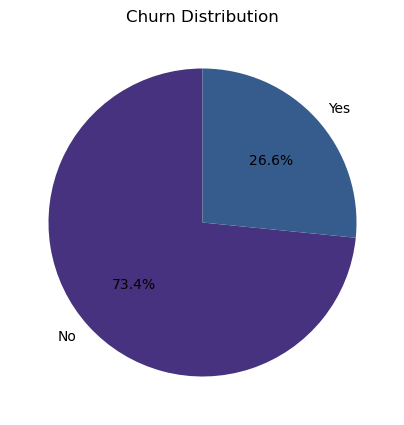

In [13]:
#Showing both yes/no churn
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
     startangle=90,
    colors=sns.color_palette('viridis'),
    figsize=(5,5)
)

plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

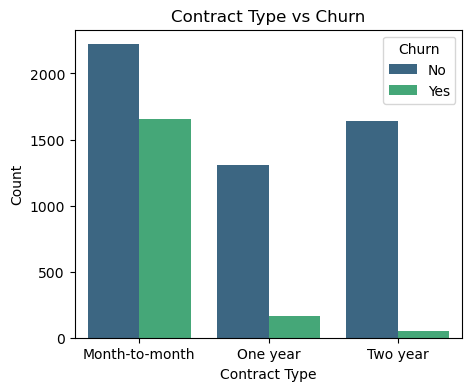

In [14]:
plt.figure(figsize=(5,4))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df,
    palette='viridis'
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

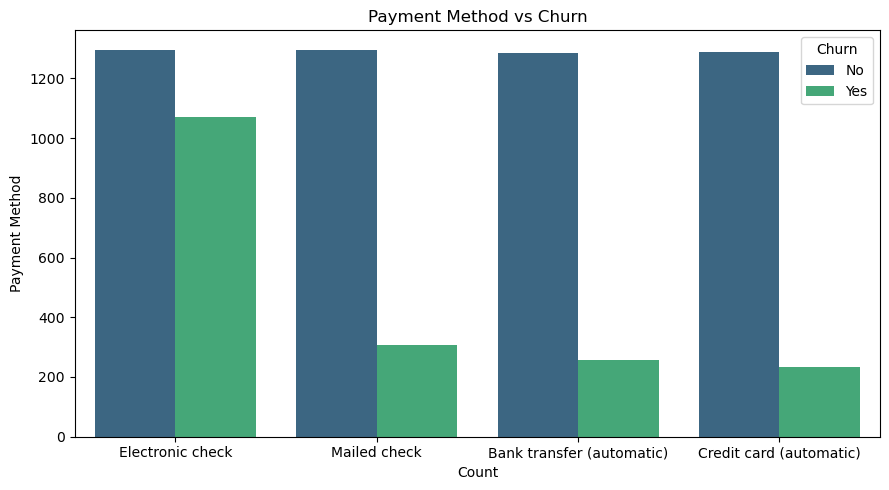

In [15]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df,
    palette='viridis'
)

plt.title("Payment Method vs Churn")
plt.xlabel("Count")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

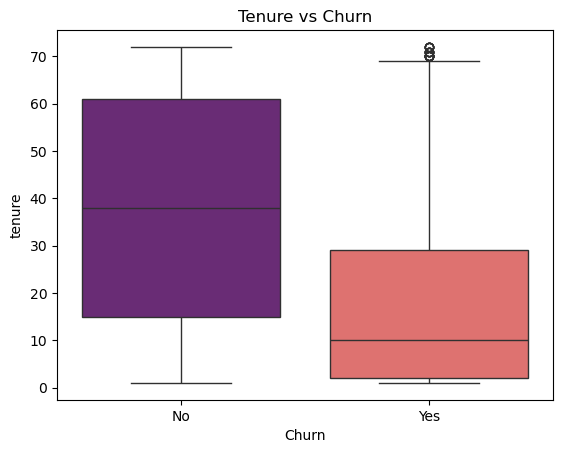

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')
plt.title("Tenure vs Churn")
plt.show()

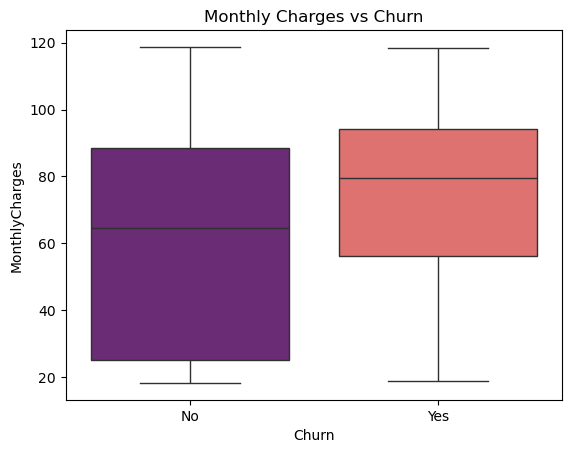

In [17]:
sns.boxplot(x='Churn' , y='MonthlyCharges', data=df, palette='magma')
plt.title("Monthly Charges vs Churn")
plt.show()

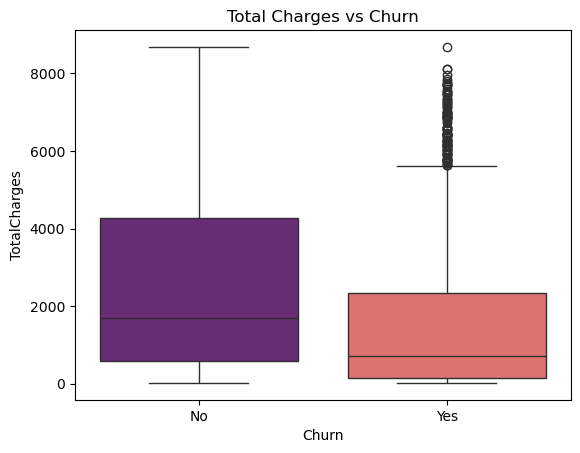

In [18]:
sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='magma')
plt.title("Total Charges vs Churn")
plt.show()

## Distributions 

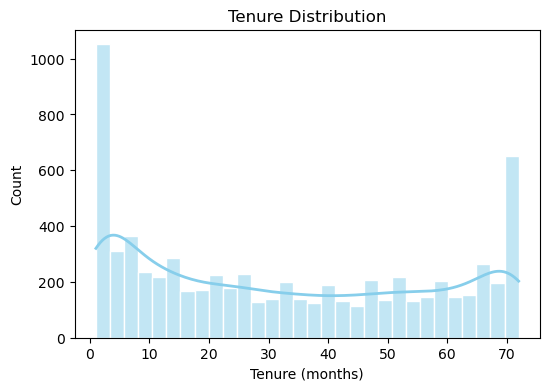

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(
    df['tenure'], 
    bins=30, 
    kde=True, 
    color='skyblue', 
    edgecolor='white',
    line_kws={'color': 'dodgerblue', 'linewidth': 2}
)
plt.title("Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

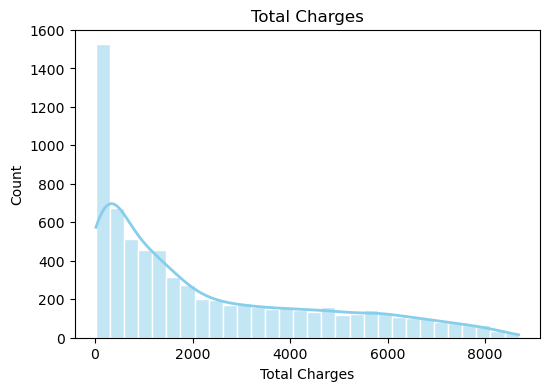

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(
    df['TotalCharges'],
    bins=30, 
    kde=True,
    color='skyblue', 
    edgecolor='white',
    line_kws={'color': 'dodgerblue', 'linewidth': 2}
)
plt.title("Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Count")
plt.show()

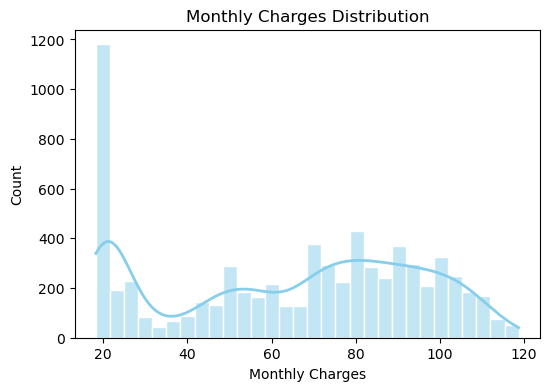

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(
    df['MonthlyCharges'], 
    bins=30, 
    kde=True,
    color='skyblue', 
    edgecolor='white',
    line_kws={'color': 'dodgerblue', 'linewidth': 2}
)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

## All Categorial ( customer distribution by various demographics )

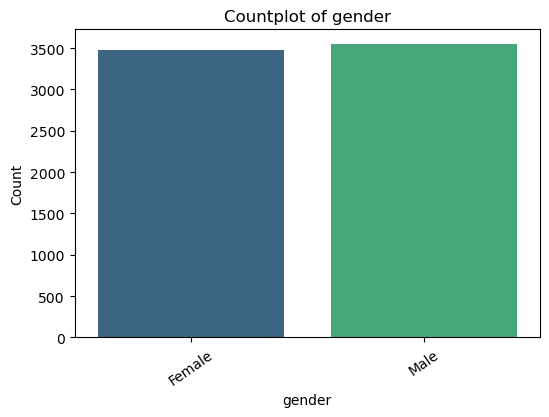

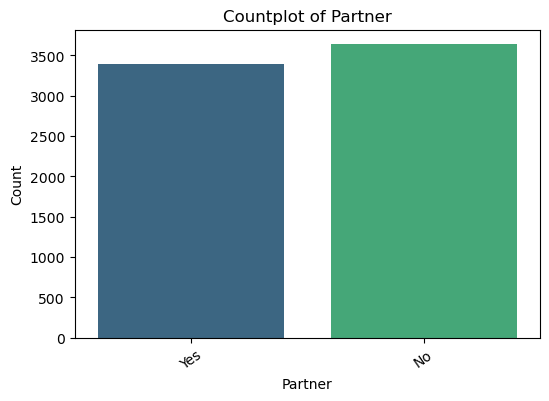

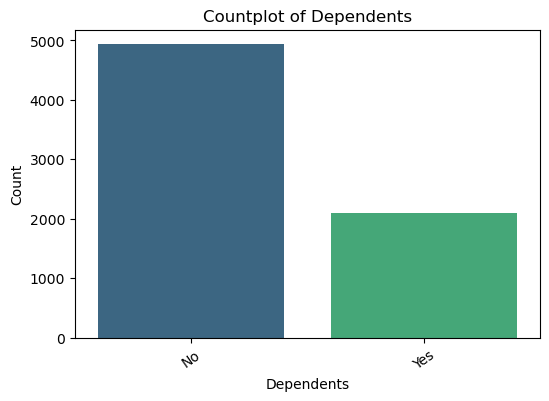

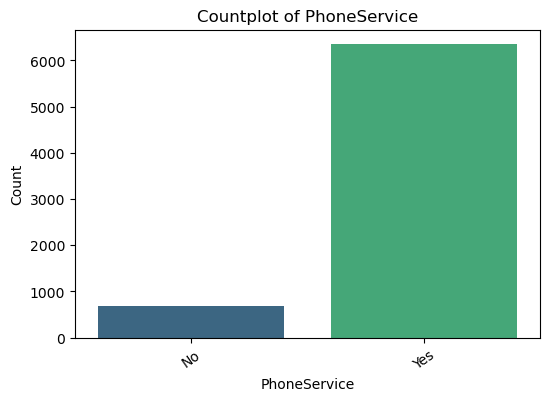

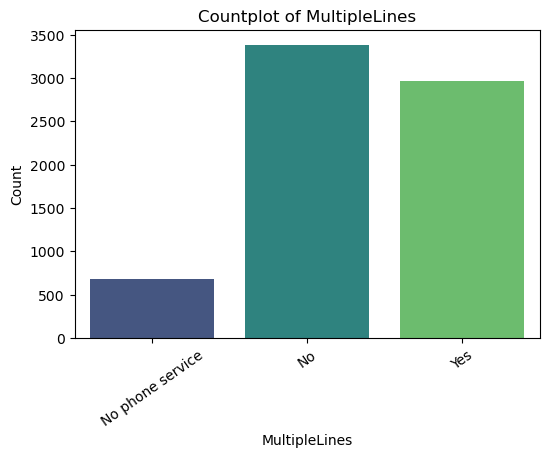

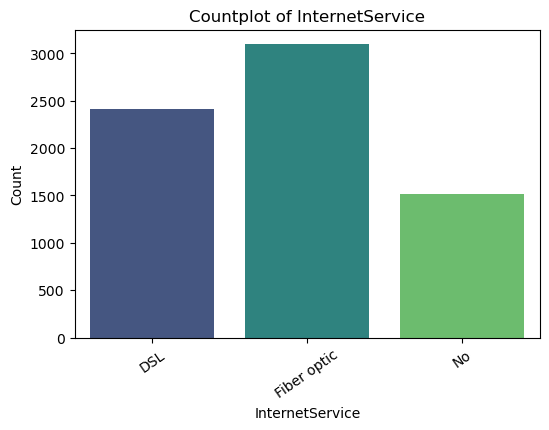

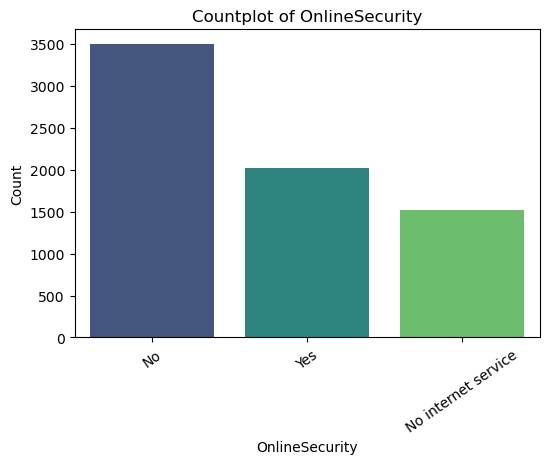

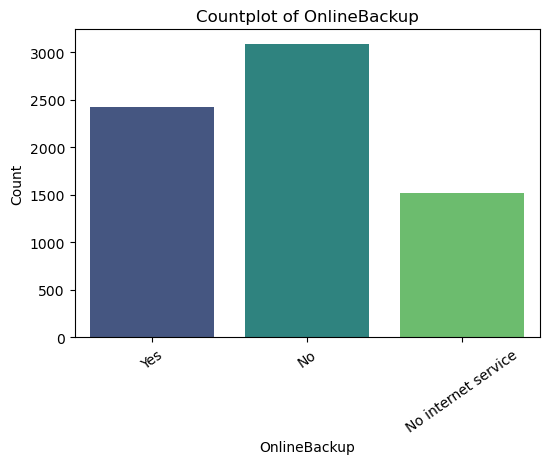

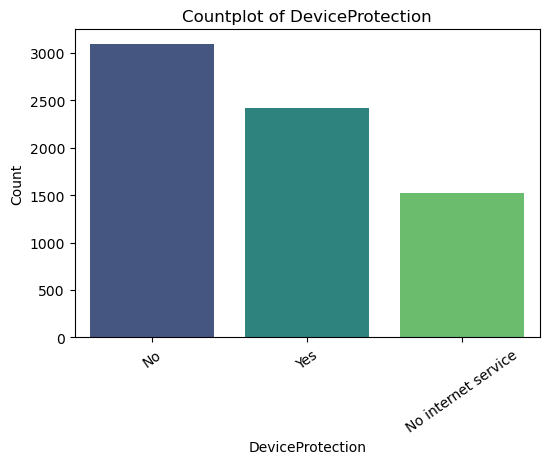

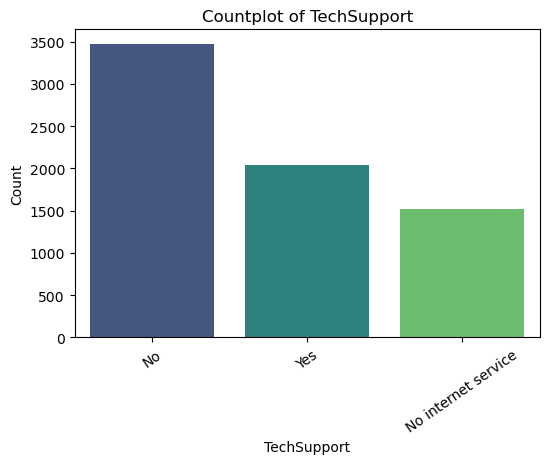

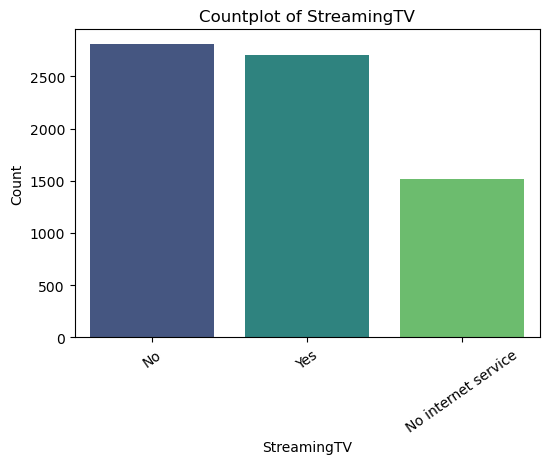

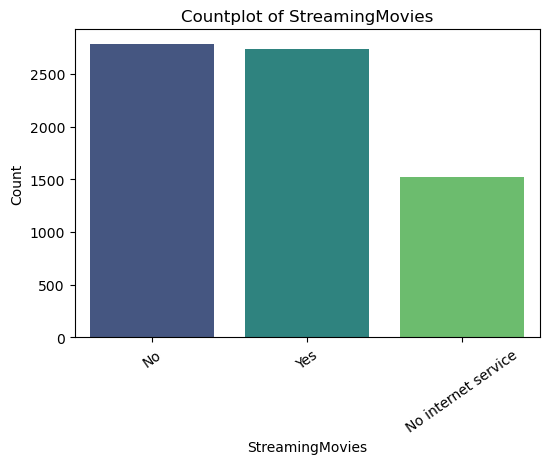

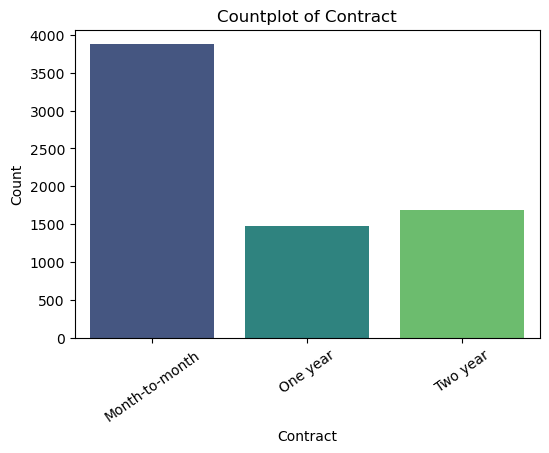

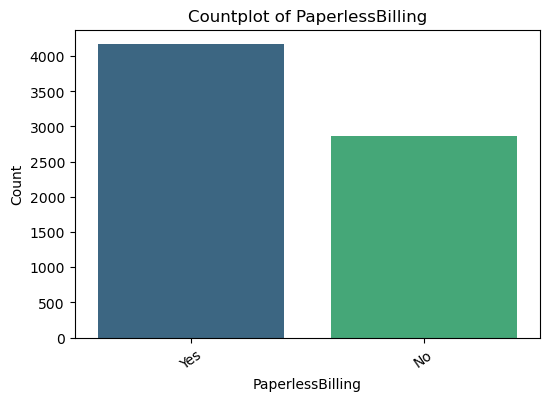

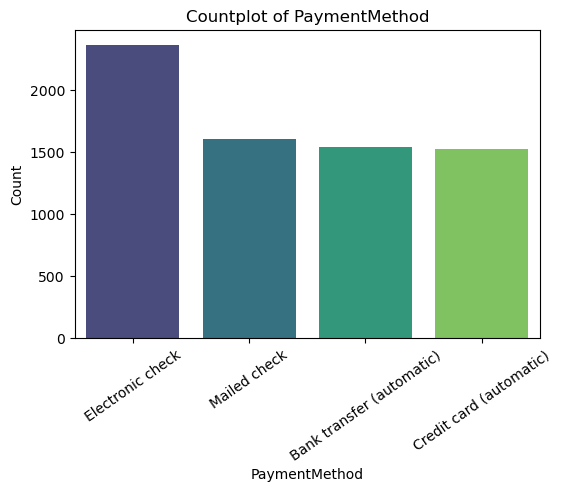

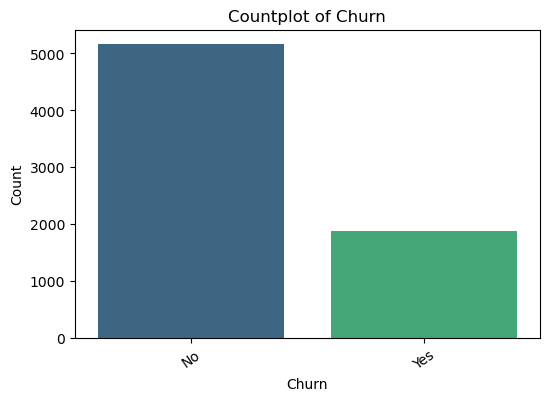

In [22]:
#all categorial 
categ_cols = df.select_dtypes(include='object').columns

for col in categ_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=df,
        palette='viridis'
    )

    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=35)
    plt.show()

## Correlation on Numeric Only

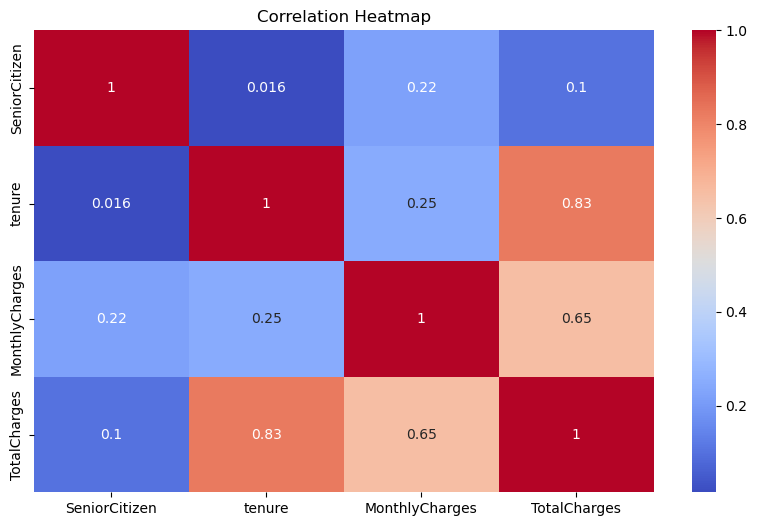

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
# df.head()

In [25]:
# df.to_csv("dfdata.csv", index=False)

## Encoding & Feature Engineering

In [26]:
#Copy data
df1 = df.copy() 

In [27]:
df1['tenure_group'] = pd.cut(df1['tenure'], 
                           bins=[0,12,24,48,60,72], 
                           labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])

In [28]:
df1['avg_monthly_spend'] = df1['TotalCharges'] / (df1['tenure'] + 1)

In [29]:
df1['high_charges'] = (df1['MonthlyCharges'] > df1['MonthlyCharges'].median()).astype(int)

In [30]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df1['total_services'] = df1[services].apply(lambda x: sum(x == 'Yes'), axis=1)

In [31]:
df1['is_monthly_contract'] = (df1['Contract'] == 'Month-to-month').astype(int)

In [32]:
df1['auto_payment'] = df1['PaymentMethod'].str.contains('automatic').astype(int)

In [33]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,high_charges,total_services,is_monthly_contract,auto_payment
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,No,0-1yr,14.925000,0,1,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,No,2-4yr,53.985714,0,3,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,Yes,0-1yr,36.050000,0,3,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,No,2-4yr,40.016304,0,3,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,Yes,0-1yr,50.550000,1,1,1,0


In [34]:
#for checking yes/no in churn (shows imbalance )
df1['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

## Label Encoding

In [35]:
binary_cols = [ 
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling', 'Churn'
]

le = LabelEncoder()

for col in binary_cols:
    df1[col] = le.fit_transform(df1[col].astype(str))


In [36]:

df1['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Binary Encoding

In [37]:
multi_cat_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines',
    'Contract', 'PaymentMethod','tenure_group' 
]

df1= pd.get_dummies(df1, columns= [c for c in multi_cat_cols if c in df1.columns], drop_first=True)

#true/false - 0/1
bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)

#ensuring no  category left 
cat_cols = df1.select_dtypes(include=['category']).columns
df1[cat_cols] = df1[cat_cols].astype(int)

print("Data shape after encoding:", df1.shape)

Data shape after encoding: (7032, 40)


In [38]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,MultipleLines_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,1,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,1,0,0,0,0,0


In [39]:
#well it showd tenure charges left with category so above we applied to change it in int in binary encoding
# print(X_train.dtypes[X_train.dtypes == 'object'])
# print(X_train.dtypes)

## Train Test Split

In [40]:
# Featuree

X = df1.drop('Churn', axis=1)
y = df['Churn']

In [41]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
#Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Logistic Regression 

In [43]:
model = LogisticRegression()

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred = model.predict(X_test)


In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
accuracy_score(y_test,y_pred)

0.7889125799573561

In [47]:
confusion_matrix(y_test,y_pred)

array([[929, 104],
       [193, 181]])

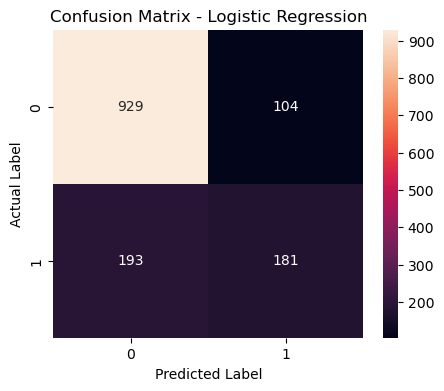

In [48]:
# confusion_matrix Vizualize 


plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [49]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Random Forest

In [50]:

# Model
rf = RandomForestClassifier( n_estimators=200, random_state=42,class_weight='balanced')

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)


In [51]:
accuracy_score(y_test,y_pred)

0.783226723525231

In [52]:
confusion_matrix(y_test,y_pred)

array([[927, 106],
       [199, 175]])

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## GBC boost 

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [55]:
y_pred = gb.predict(X_test)

In [56]:
accuracy_score(y_test,y_pred)

0.7924662402274343

In [57]:
confusion_matrix(y_test,y_pred)

array([[937,  96],
       [196, 178]])

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1033
         Yes       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## High risk customer

In [59]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [60]:
# Step 1: probability add 
test_results = X_test.copy()
test_results['Churn_Probability'] = model.predict_proba(X_test_scaled)[:, 1]

# Step 2: high-risk cutoff
high_risk_cutoff = 0.70
high_risk_customers = test_results[test_results['Churn_Probability'] > high_risk_cutoff]

# Step 3: percentage nikaalo
high_risk_rate = len(high_risk_customers) / len(df1) * 100

print(f"High-Risk Customers (> {high_risk_cutoff} prob): {high_risk_rate:.2f}%")
print("Total High Risk Customers:", len(high_risk_customers))

High-Risk Customers (> 0.7 prob): 8.16%
Total High Risk Customers: 574


## Savings and Benifits 

In [61]:

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

saved_customers = tp
avg_monthly_revenue = df1['MonthlyCharges'].mean()

# assume customer lifetime loss = 3 months
loss_per_customer = avg_monthly_revenue * 6

monthly_savings = saved_customers * loss_per_customer
annual_savings = monthly_savings * 12

print("Estimated Monthly Savings:", monthly_savings)
print("Projected Annual Benefit:", annual_savings)

Estimated Monthly Savings: 69204.48634812287
Projected Annual Benefit: 830453.8361774744


## well without using smote data shows imbalance in prediction so we will also check with smote 

In [62]:
#using SMOTE 
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

## Logistic 

In [63]:
model1 = LogisticRegression()
model1.fit(X_train_sm,y_train_sm)
y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Random

In [64]:
# Model
rf1 = RandomForestClassifier()

# Train
rf1.fit(X_train_sm, y_train_sm)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Business Insights

## Objective 
The goal of this project is to analyze customer churn behavior and identify key factors driving customer attrition, and to build a predictive model that helps the company proactively retain high-risk customers.

## Overall Churn Rate

Around ~26–27% customers are churning.

## Revenue & Pricing Impact

Customers with higher MonthlyCharges and TotalCharges show higher churn. 

## Contract Type

Month-to-month customers have the highest churn rate
Two-year contract customers have the lowest churn

Insight:
Lack of long-term commitment increases churn risk.

## Demographics

Features like gender, partner, dependents have minimal impact

## Machine Learning Model Summary 

Tthree models were tested:

Logistic Regression
Random Forest
Gradient boosting

## High-Risk Customer

Using churn probability:

8.16% customers identified as high-risk
Total high-risk customers: ~574

These customers require immediate retention actions.

## Business Impact (Revenue Estimation)

Estimated Monthly Savings: ₹69,000 approx
Projected Annual Benefit: ₹8.3 Lakhs approx

## Key Recommendations

Customer Retention Strategy:-
Offer discounts for high-paying customers , 
Promote long-term contracts (annual/2-year plans).

Payment Strategy:0
Encourage automatic payment methods , 
Reduce reliance on electronic check users.

Risk-Based Targeting:-
Focus on high-risk customers (probability > 0.7) ,
Run targeted retention campaigns

In [68]:
import joblib

joblib.dump(gb, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns, "df1.pkl")

['df1.pkl']